In [1]:
!unzip -q "hot-dog-not-hot-dog.zip" -d /content/

# Importing Libraries

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random

!pip install ultralytics -q
from ultralytics import YOLO #for extra credit

print("Libraries loaded sucessfully!")
print("TensorFlow version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries loaded sucessfully!
TensorFlow version: 2.20.0


#  Load and Explore the Data

In [3]:
import os

train_path = "/content/seefood/train"
test_path  = "/content/seefood/test"

# Count train images
hot_dog_count     = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images (train):     {hot_dog_count}")
print(f"Not hot dog images (train): {not_hot_dog_count}")

# Count test images
test_hot_dog_count     = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))
print(f"Hot dog images (test):      {test_hot_dog_count}")
print(f"Not hot dog images (test):  {test_not_hot_dog_count}")

Hot dog images (train):     249
Not hot dog images (train): 249
Hot dog images (test):      250
Not hot dog images (test):  250


# Data Visualization

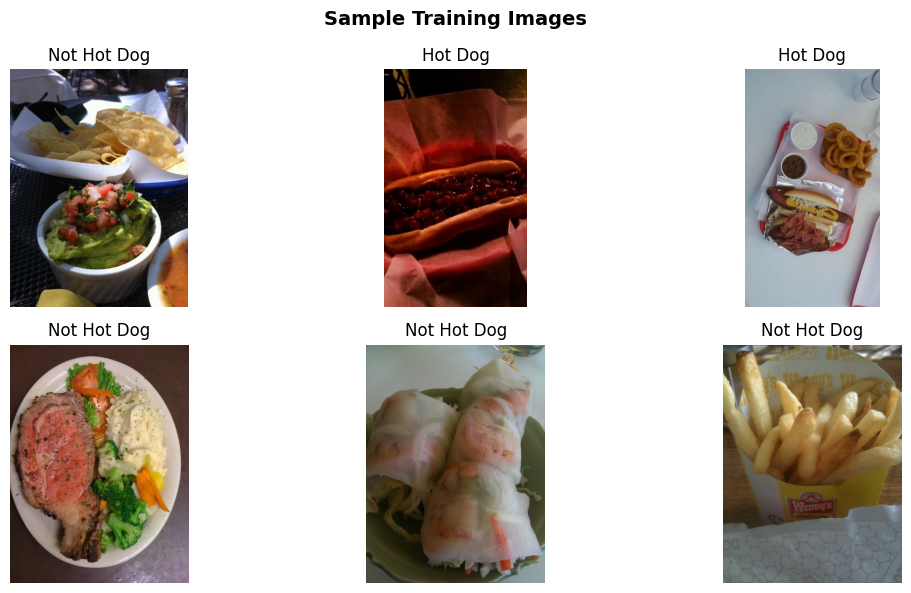

Image shape (height, width, channels): (512, 384, 3)


In [4]:
plt.figure(figsize=(12, 6))
for i in range(6):
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name   = random.choice(os.listdir(class_path))
    img_path   = os.path.join(class_path, img_name)

    img = plt.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name.replace("_", " ").title())
    plt.axis('off')

plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("step4_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

# Print shape of one image
print("Image shape (height, width, channels):", img.shape)

# Preparing the Data Generators

In [5]:
IMG_HEIGHT = 64
IMG_WIDTH  = 64
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class indices: {'hot_dog': 0, 'not_hot_dog': 1}


# Buildling ANN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.5500 - loss: 1.6883 - val_accuracy: 0.5102 - val_loss: 0.9532
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.5450 - loss: 1.0363 - val_accuracy: 0.4898 - val_loss: 0.9909
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.5475 - loss: 0.8961 - val_accuracy: 0.5612 - val_loss: 0.7893
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.6075 - loss: 0.7328 - val_accuracy: 0.5000 - val_loss: 1.0174
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.6450 - loss: 0.6358 - val_accuracy: 0.5510 - val_loss: 0.8179
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6950 - loss: 0.5882 - val_accuracy: 0.5204 - val_loss: 0.7515
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7225 - loss: 0.5426 - val_accuracy: 0.5612 - val_loss: 0.7375
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.7275 - loss: 0.5347 - val_accuracy: 0.5306

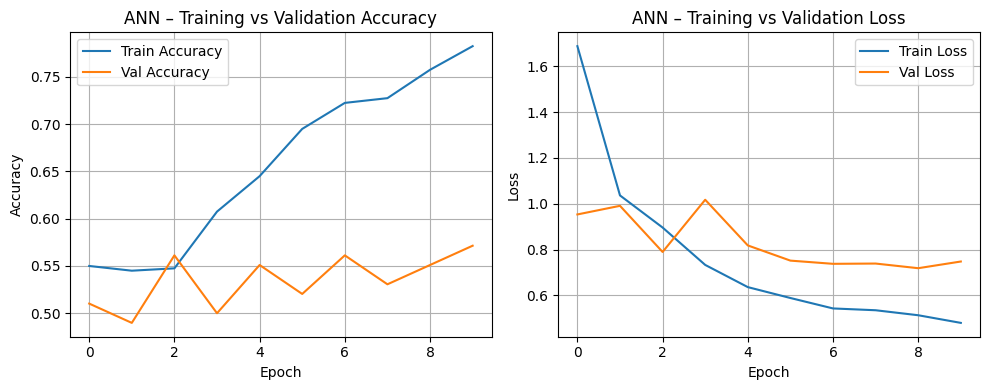

ANN Final Validation Accuracy: 57.14 %


In [6]:
ann_model = keras.Sequential([
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(1,   activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Plot ANN training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ann.history['accuracy'],     label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('ANN – Training vs Validation Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_ann.history['loss'],     label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('ANN – Training vs Validation Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig("step6_ann_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("ANN Final Validation Accuracy:",
      round(history_ann.history['val_accuracy'][-1] * 100, 2), "%")

# Building CNN

In [7]:
cnn_model = keras.Sequential([
    # First Conv Block
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Conv Block  ← YOUR TURN (filled in)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

print("CNN Final Validation Accuracy:",
      round(history_cnn.history['val_accuracy'][-1] * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - accuracy: 0.4675 - loss: 0.7064 - val_accuracy: 0.4898 - val_loss: 0.6912
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.4950 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.5200 - loss: 0.6876 - val_accuracy: 0.5000 - val_loss: 0.6843
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.5600 - loss: 0.6880 - val_accuracy: 0.5510 - val_loss: 0.6897
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.6425 - loss: 0.6628 - val_accuracy: 0.5408 - val_loss: 0.6679
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.6725 - loss: 0.6320 - val_accuracy: 0.5918 - val_loss: 0.6843
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.6625 - loss: 0.6343 - val_accuracy: 0.5714 - val_loss: 0.6720
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step - accuracy: 0.6850 - loss: 0.5886 - val_accuracy: 0.

## Comparison Plots

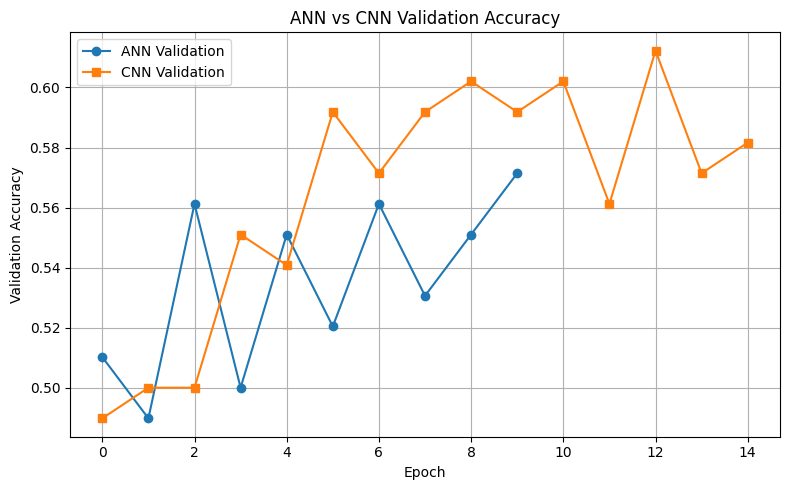

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig("step7_ann_vs_cnn.png", dpi=150, bbox_inches='tight')
plt.show()

# Dropout

In [9]:
from tensorflow.keras import regularizers

improved_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),                          # Fix 1

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),                          # Fix 2

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),                           # Fix 3
    layers.Dense(1, activation='sigmoid')
])

improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.4950 - loss: 0.7035 - val_accuracy: 0.5306 - val_loss: 0.6917
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.5400 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6888
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 332ms/step - accuracy: 0.5300 - loss: 0.6835 - val_accuracy: 0.6224 - val_loss: 0.6771
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.6200 - loss: 0.6603 - val_accuracy: 0.5510 - val_loss: 0.6819
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.6000 - loss: 0.6616 - val_accuracy: 0.6224 - val_loss: 0.6642
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.6275 - loss: 0.6448 - val_accuracy: 0.6327 - val_loss: 0.6505
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - accuracy: 0.6350 - loss: 0.6391 - val_accuracy: 0.6122 - val_loss: 0.6659
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.6425 - loss: 0.6389 - val_accuracy: 0.

# Dropout + Data Augmentation

In [10]:
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = final_model.fit(
    train_augmented,
    validation_data=validation_generator,
    epochs=15
)

print("Final Model Validation Accuracy:",
      round(history_final.history['val_accuracy'][-1] * 100, 2), "%")

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 390ms/step - accuracy: 0.5450 - loss: 0.7110 - val_accuracy: 0.5612 - val_loss: 0.6898
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.5225 - loss: 0.6953 - val_accuracy: 0.5816 - val_loss: 0.6909
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step - accuracy: 0.4925 - loss: 0.6929 - val_accuracy: 0.5408 - val_loss: 0.6896
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step - accuracy: 0.5850 - loss: 0.6861 - val_accuracy: 0.5816 - val_loss: 0.6862
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.5300 - loss: 0.6870 - val_accuracy: 0.5816 - val_loss: 0.6810
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - accuracy: 0.5800 - loss: 0.6793 - val_accuracy: 0.6122 - val_loss: 0.6658
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.6100 - loss: 0.6586 - val_accuracy: 0.6020 - val_loss: 0.6636
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy:

# Before vs After Overfitting Fix Plot

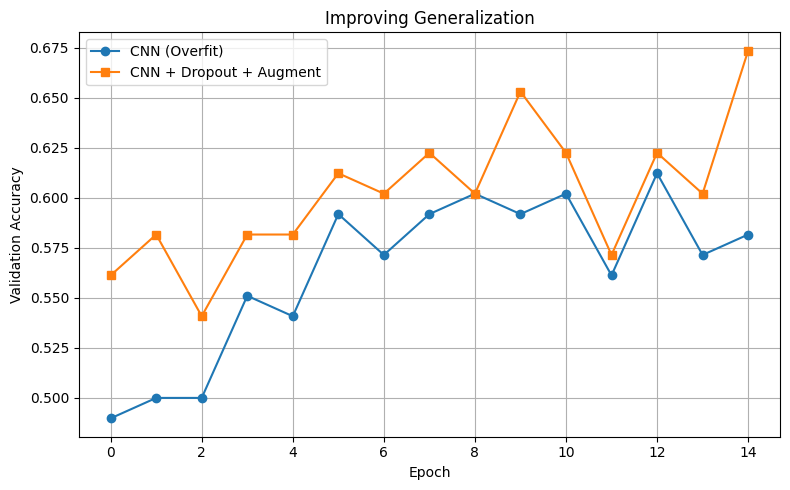

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['val_accuracy'],
         label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'],
         label='CNN + Dropout + Augment', marker='s')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.title('Improving Generalization')
plt.grid(True)
plt.tight_layout()
plt.savefig("step8_overfitting_fix.png", dpi=150, bbox_inches='tight')
plt.show()

# Test on Real Images

In [12]:
from tensorflow.keras.preprocessing import image
import os

def predict_local_image(img_path="real_image.png"):
    if not os.path.exists(img_path):
        print(f"Error: '{img_path}' not found. Please upload an image with that name to the /content/ folder.")
        return

    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = final_model.predict(img_array)[0][0]
    if prediction > 0.5:
        label = f"NOT A HOT DOG (confidence: {prediction:.2f})"
    else:
        label = f"HOT DOG!      (confidence: {1 - prediction:.2f})"

    print(label)
    plt.imshow(img)
    plt.title(label, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Prediction on real image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
HOT DOG!      (confidence: 0.60)


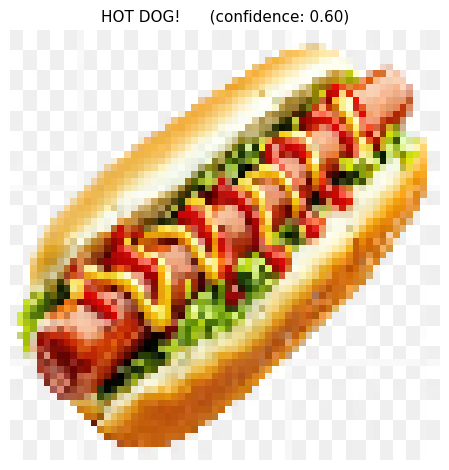

In [13]:
# Simply upload a file named 'real_image.png' to the sidebar then run this:
predict_local_image("real_image.png")

# YOLO BONUS

Testing YOLO on: /content/seefood/test/hot_dog/573731.jpg

image 1/1 /content/seefood/test/hot_dog/573731.jpg: 640x640 1 hot dog, 1 dining table, 674.3ms
Speed: 63.2ms preprocess, 674.3ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)


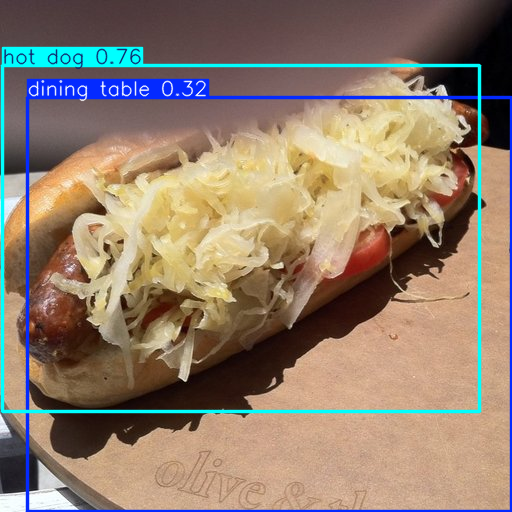

In [18]:
# Initialize the model
yolo_model = YOLO("yolov8n.pt")

# Dynamically grab a random hot dog image from your test folder
test_hot_dog_dir = os.path.join(test_path, "hot_dog")
random_image = random.choice(os.listdir(test_hot_dog_dir))
image_to_test = os.path.join(test_hot_dog_dir, random_image)

print(f"Testing YOLO on: {image_to_test}")

# Run inference
results = yolo_model(image_to_test)

# Display results
results[0].show()